In [1]:
import numpy as np
import pandas as pd
coor = np.array([
    [1, 3, 2, 8, 6, 7, -3, -2, -7],
    [2, 3, 2, 8, 6, 7, -3, -4, -7]
]).T
# starting = np.array([
#     [3, 2, -3],
#     [3, 2, -3]
# ])
starting = np.array([
    [-3, 2, -7],
    [-3, 2, -7]
])

dx = coor[:, 0:1] - starting[0:1]
dy = coor[:, 1:2] - starting[1:2]
eu_dist = np.sqrt(dx**2 + dy**2)
eu_dist_frame = pd.DataFrame(eu_dist, columns=[f"start_point_{start}" for start in starting.T])

print(f"euclidean distance: data point - start point")
eu_dist_frame

euclidean distance: data point - start point


,start_point_[-3 -3],start_point_[2 2],start_point_[-7 -7]
0,6.403124,1.000000,12.041595
1,8.485281,1.414214,14.142136
2,7.071068,0.000000,12.727922
3,15.556349,8.485281,21.213203
4,12.727922,5.656854,18.384776
5,14.142136,7.071068,19.798990
6,0.000000,7.071068,5.656854
7,1.414214,7.211103,5.830952
8,5.656854,12.727922,0.000000


In [2]:
dist_min_idx = eu_dist.argmin(axis=1)
for idx, min_idx in enumerate(dist_min_idx):
    print(f"Point {coor[idx]} is closest to point {starting.T[min_idx]}")

Point [1 2] is closest to point [2 2]
Point [3 3] is closest to point [2 2]
Point [2 2] is closest to point [2 2]
Point [8 8] is closest to point [2 2]
Point [6 6] is closest to point [2 2]
Point [7 7] is closest to point [2 2]
Point [-3 -3] is closest to point [-3 -3]
Point [-2 -4] is closest to point [-3 -3]
Point [-7 -7] is closest to point [-7 -7]


In [3]:
k = starting.shape[1]
new_centroids = np.zeros((2, k))

for j in range(k):
    assigned_points = coor[dist_min_idx == j]
    
    if len(assigned_points) > 0:
        new_centroids[:, j] = assigned_points.mean(axis=0)
    else:
        new_centroids[:, j] = starting[:, j]
print("New centroids:")
new_centroids.T

New centroids:


array([[-2.5       , -3.5       ],
       [ 4.5       ,  4.66666667],
       [-7.        , -7.        ]])

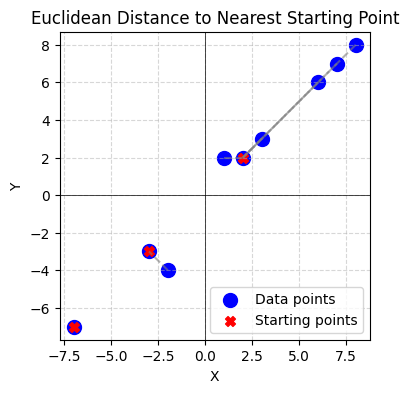

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# plot data points
plt.figure(figsize=(4, 4))
plt.scatter(coor[:, 0], coor[:, 1], c="blue", label="Data points", s=100)

# plot starting points
plt.scatter(
    starting[0], starting[1],
    c="red", marker="X", s=50, label="Starting points"
)

# draw line from each point to its nearest starting point
for i, min_idx in enumerate(dist_min_idx):
    plt.plot(
        [coor[i, 0], starting[0, min_idx]],
        [coor[i, 1], starting[1, min_idx]],
        c="gray", linestyle="--", alpha=0.6
    )

# decoration
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Euclidean Distance to Nearest Starting Point")
plt.axis("equal")

plt.show()

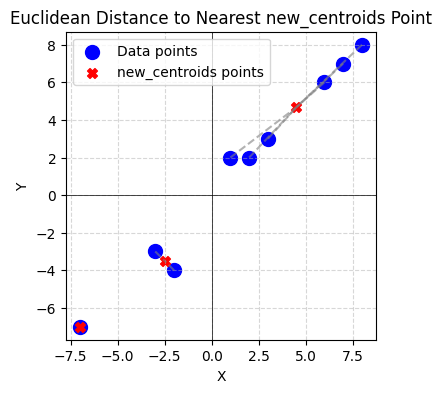

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# plot data points
plt.figure(figsize=(4, 4))
plt.scatter(coor[:, 0], coor[:, 1], c="blue", label="Data points", s=100)

# plot new_centroids points
plt.scatter(
    new_centroids[0], new_centroids[1],
    c="red", marker="X", s=50, label="new_centroids points"
)

# draw line from each point to its nearest new_centroids point
for i, min_idx in enumerate(dist_min_idx):
    plt.plot(
        [coor[i, 0], new_centroids[0, min_idx]],
        [coor[i, 1], new_centroids[1, min_idx]],
        c="gray", linestyle="--", alpha=0.6
    )

# decoration
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Euclidean Distance to Nearest new_centroids Point")
plt.axis("equal")

plt.show()